### dataset got from https://amazon-reviews-2023.github.io/ CDs_and_Vinyl

In [18]:
import json
import pandas as pd

In [19]:
with open("../data/meta_CDs_and_Vinyl.jsonl") as f:
    first_line=json.loads(f.readline())



In [20]:
first_line

{'main_category': 'Digital Music',
 'title': 'Release Some Tension',
 'average_rating': 4.6,
 'rating_number': 112,
 'features': [],
 'description': ['Swv ~ Release Some Tension'],
 'price': 12.05,
 'images': [{'thumb': 'https://m.media-amazon.com/images/I/517h9OROQAL._SS40_.jpg',
   'large': 'https://m.media-amazon.com/images/I/517h9OROQAL.jpg',
   'variant': 'MAIN',
   'hi_res': 'https://m.media-amazon.com/images/I/71VRDLrTvYL._SL1500_.jpg'}],
 'videos': [],
 'store': 'SWV   Format: Audio CD',
 'categories': ['CDs & Vinyl', 'Dance & Electronic', 'House'],
 'details': {'Is Discontinued By Manufacturer': 'No',
  'Product Dimensions': '5.62 x 4.92 x 0.33 inches; 3.84 Ounces',
  'Manufacturer': 'Sony Legacy',
  'Item model number': '2013033',
  'Original Release Date': '1997',
  'Run time': '53 minutes',
  'Date First Available': 'December 7, 2006',
  'Label': 'Sony Legacy',
  'Number of discs': '1'},
 'parent_asin': 'B000002X4C',
 'bought_together': None}

### Filter items that have been observed for the first time in year 2022 or later.


In [21]:
#to filter out data with date on or after 2022
def filter_data(data:dict)-> dict:
    filter=False
    if int(data["details"]['Date First Available'][-4:])<2022:
        filter=True

    return filter

In [22]:

with open("./../data/meta_CDs_and_Vinyl.jsonl", 'r') as fp:
    with open("./../data/meta_CDs_and_Vinyl_2022_2023.jsonl", 'a', encoding='utf-8') as fp_out:
        with open("./../data/meta_CDs_and_Vinyl_2022_2023_no_date.jsonl", 'a', encoding='utf-8') as fp_out_no_date:
            i = 0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    filter = filter_data(data)
                    if not filter:
                        json.dump(data, fp_out)
                        fp_out.write('\n')
                        fp_out.flush()
                except:
                    json.dump(data, fp_out_no_date)
                    fp_out_no_date.write('\n')
                    fp_out_no_date.flush()
                i += 1
                if i % 10000 == 0:
                    print(f"Processed {i} lines")

Processed 10000 lines
Processed 20000 lines
Processed 30000 lines
Processed 40000 lines
Processed 50000 lines
Processed 60000 lines
Processed 70000 lines
Processed 80000 lines
Processed 90000 lines
Processed 100000 lines
Processed 110000 lines
Processed 120000 lines
Processed 130000 lines
Processed 140000 lines
Processed 150000 lines
Processed 160000 lines
Processed 170000 lines
Processed 180000 lines
Processed 190000 lines
Processed 200000 lines
Processed 210000 lines
Processed 220000 lines
Processed 230000 lines
Processed 240000 lines
Processed 250000 lines
Processed 260000 lines
Processed 270000 lines
Processed 280000 lines
Processed 290000 lines
Processed 300000 lines
Processed 310000 lines
Processed 320000 lines
Processed 330000 lines
Processed 340000 lines
Processed 350000 lines
Processed 360000 lines
Processed 370000 lines
Processed 380000 lines
Processed 390000 lines
Processed 400000 lines
Processed 410000 lines
Processed 420000 lines
Processed 430000 lines
Processed 440000 lin

### Split items in 2 cat , has main cat or doesnt have main cat

In [23]:
# Split items in 2 cat , has main cat or doesnt have main cat
def filter_data(data:dict)-> dict:
    filter=False
    if data['main_category'] is None:
        filter=True

    return filter

In [24]:

with open("./../data/meta_CDs_and_Vinyl_2022_2023.jsonl", 'r') as fp:
    with open("./../data/meta_CDs_and_Vinyl_2022_2023_with_category.jsonl", 'a', encoding='utf-8') as fp_out:
        with open("./../data/meta_CDs_and_Vinyl_2022_2023_with_no_category.jsonl", 'a', encoding='utf-8') as fp_out_no_date:
            i = 0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    filter = filter_data(data)
                    if not filter:
                        json.dump(data, fp_out)
                        fp_out.write('\n')
                        fp_out.flush()
                except:
                    json.dump(data, fp_out_no_date)
                    fp_out_no_date.write('\n')
                    fp_out_no_date.flush()
                i += 1
                if i % 10000 == 0:
                    print(f"Processed {i} lines")

### Explore Distribution by categories

In [25]:
df=pd.read_json("./../data/meta_CDs_and_Vinyl_2022_2023_with_category.jsonl",lines=True)

In [26]:
df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Digital Music,Cracker Black,4.7,90,[],[Limited 180gm black vinyl LP pressing. Cracke...,25.00,[{'thumb': 'https://m.media-amazon.com/images/...,[],Cracker Format: Vinyl,"[CDs & Vinyl, Rock]",{'Product Dimensions': '12.5 x 12.5 x 0.13 inc...,B09X7MMY8Z,NaN
1,Digital Music,I NEVER LIKED YOU Explicit Lyrics,4.8,171,[],[EPIC RECORDS FUTURE - I NEVER LIKED YOU - Fut...,12.98,[{'thumb': 'https://m.media-amazon.com/images/...,[],Future Format: Audio CD,"[CDs & Vinyl, Rap & Hip-Hop]","{'Language': 'Japanese', 'Product Dimensions':...",B09Z6X7V1N,NaN
2,Digital Music,Terror Twilight: Farewell Horizontal,4.7,102,[],[Matador’s complete series of expanded edition...,16.94,[{'thumb': 'https://m.media-amazon.com/images/...,[],Pavement Format: Audio CD,"[CDs & Vinyl, Indie & Alternative, Alternative...","{'Language': 'English', 'Product Dimensions': ...",B09PK44XXK,NaN
3,Digital Music,C’MON YOU KNOW (Amazon Ocean Blue,4.7,399,[],[],28.63,[{'thumb': 'https://m.media-amazon.com/images/...,[],Liam Gallagher Format: Vinyl,"[CDs & Vinyl, Rock]","{'Language': 'English', 'Product Dimensions': ...",B09QQT2TM7,NaN
4,Digital Music,Radio Transient,5.0,1,[],"[2023 release from celebrated Lenoir, North Ca...",11.98,[{'thumb': 'https://m.media-amazon.com/images/...,[],Chris Church (Artist) Format: Audio CD,"[CDs & Vinyl, Rock]",{'Product Dimensions': '4.9 x 5.5 x 0.25 inche...,B0BS464JWJ,NaN


In [27]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'Distribution of Main Categories'}, xlabel='main_category'>

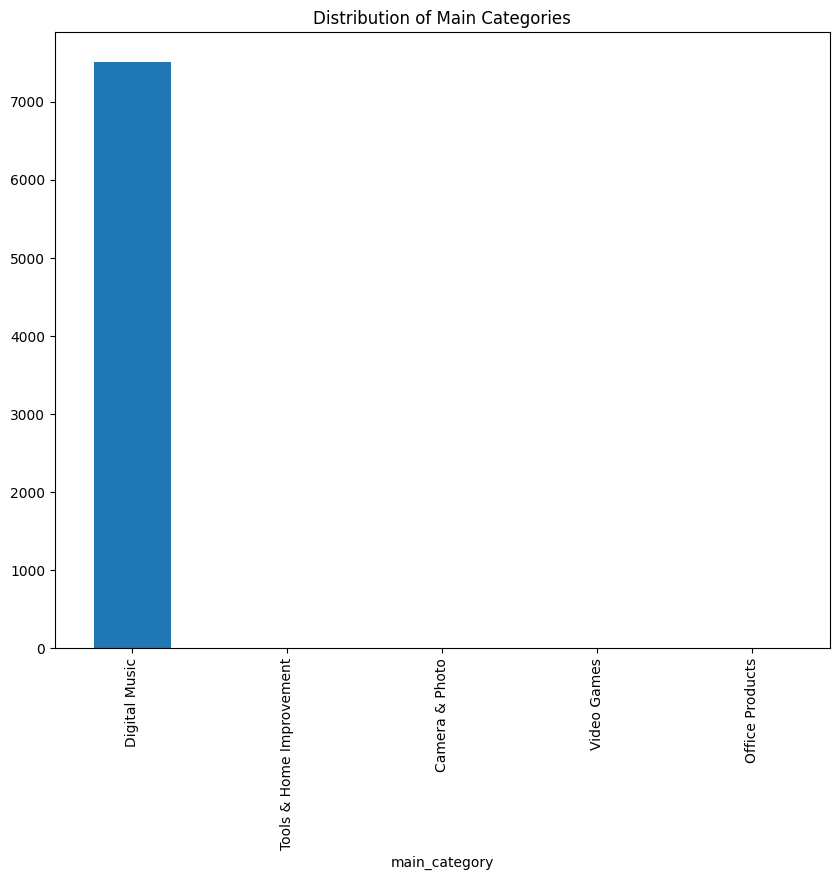

In [28]:
df["main_category"].value_counts().plot(kind='bar', figsize=(10, 8), title='Distribution of Main Categories')

In [29]:
df_ratings_100=df[df['rating_number']>=100]

In [30]:
len(df)

7521

In [31]:
len(df_ratings_100)

2417

### Distribution of ratiings

<Axes: ylabel='Frequency'>

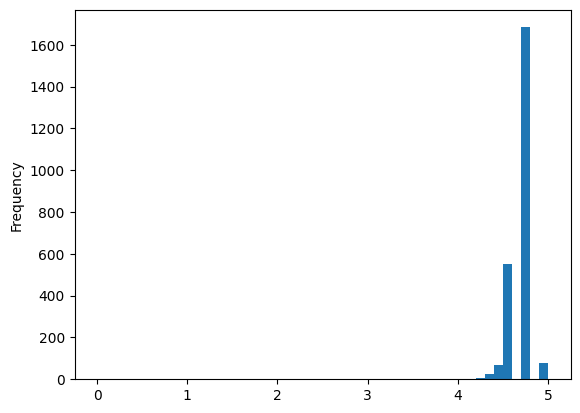

In [37]:
### Distribution of ratiings
df_ratings_100['average_rating'].plot(kind='hist', bins=50, range=(0, 5))

### Sample 1000 items

In [38]:
#Sample 1000 items
df_sample_1000=df_ratings_100.sample(n=1000, random_state=20)

<Axes: ylabel='Frequency'>

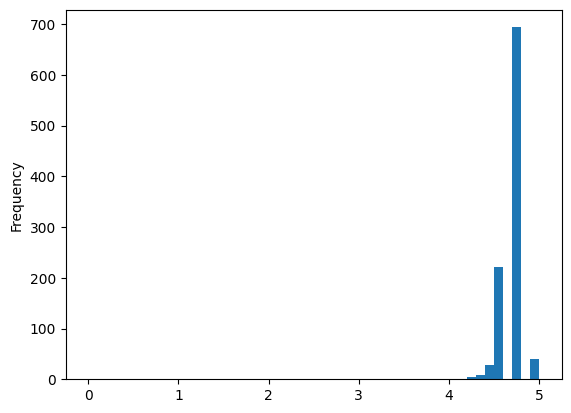

In [39]:
df_sample_1000['average_rating'].plot(kind='hist', bins=50, range=(0, 5))

<Axes: ylabel='Frequency'>

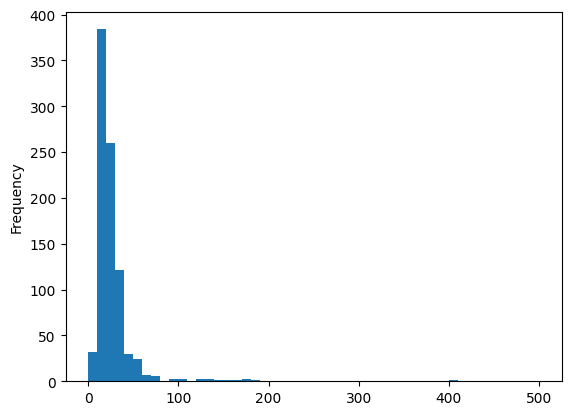

In [40]:
df_sample_1000['price'].plot(kind='hist', bins=50, range=(0, 500))

In [41]:
df_ratings_100.to_json("./../data/meta_CDs_and_Vinyl_2022_2023_with_category_ratings_100.jsonl", orient='records', lines=True)

In [42]:
df_sample_1000.to_json("./../data/meta_CDs_and_Vinyl_2022_2023_with_category_ratings_100_sample_1000.jsonl", orient='records', lines=True)

### Extract ratings that match sampled data

In [43]:
df_ratings_100=pd.read_json("./../data/meta_CDs_and_Vinyl_2022_2023_with_category_ratings_100.jsonl", lines=True)
df_sample_1000=pd.read_json("./../data/meta_CDs_and_Vinyl_2022_2023_with_category_ratings_100_sample_1000.jsonl", lines=True)

In [44]:
### Extract ratings that match sampled data
with open("./../data/CDs_and_Vinyl.jsonl", 'r') as fp:
    with open("./../data/CDs_and_Vinyl_2022_2023_with_category_ratings_100.jsonl", 'a', encoding='utf-8') as fp_out:
        id_list = set(df_ratings_100['parent_asin'].values)
        i = 0
        for line in fp:
            data = json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data, fp_out)
                fp_out.write('\n')
                fp_out.flush()
                i += 1
                if i % 100000 == 0:
                    print(f"Processed {i} lines")

In [45]:

with open("./../data/CDs_and_Vinyl_2022_2023_with_category_ratings_100.jsonl", 'r') as fp:
    with open("./../data/CDs_and_Vinyl_2022_2023_with_category_ratings_10_sample_1000.jsonl", 'a', encoding='utf-8') as fp_out:
        id_list = set(df_sample_1000['parent_asin'].values)
        i = 0
        for line in fp:
            data = json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data, fp_out)
                fp_out.write('\n')
                fp_out.flush()
                i += 1
                if i % 100000 == 0:
                    print(f"Processed {i} lines")